# Langraph Fundamentals

In [2]:
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage
from dotenv import load_dotenv
import os

# from langgraph.types import interrupt, Command
# from langgraph.checkpoint.memory import InMemorySaver


In [3]:
os.environ["LANGSMITH_TRACING"] = "false" # true  
os.environ["LANGSMITH_PROJECT"] = "Langraph-Workshop-Dec20"
load_dotenv()

True

# Tools

In [4]:
from datetime import datetime
from langchain.tools import tool

In [5]:
@tool
def get_time_off_balance(user_id: str) -> int:
    '''
    Get the time off balance for a user. 

    Args :
        user_id: A unique string representing the user id

    Returns:
        An integer value representing the time-off balance
    '''
    return 10

@tool
def process_time_off(user_id: str, start_date: str, end_date: str) -> dict:
    '''
    Process time-off request for a user

    Args :
        user_id: A unique string representing the user id
        start_date: A date string in YYYY-MM-DD format for the start date of the time-off request
        end_date: A date string in YYYY-MM-DD format for the end date of the time-off request

    Returns:
        A dictionary with the following keys:
        - status: A string value representing the status of the time-off request
        - message: A string value representing the message of the time-off request
    '''
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")

    days_requested = end_date - start_date
    time_off_balance = get_time_off_balance.invoke({"user_id": user_id})

    result = {}

    if days_requested.days + 1 > time_off_balance:
        result['status'] = 'error'
        result['message'] = f'Time off request failed. you only have {time_off_balance} days of remaining leaves but requested {days_requested.days} days'

    else:
        time_off_balance -= days_requested.days + 1
        result['status'] = 'success'
        result['message'] = f'Time off request processed successfully for {days_requested.days + 1} days. Your remaining time off balance is {time_off_balance}'


    return result


# State

In [6]:
from typing import Annotated, TypedDict, Optional
from langchain.messages import AnyMessage
import operator

In [7]:
class GraphState(TypedDict):
    chat_history: Annotated[list[AnyMessage], operator.add]
    user_id: Optional[str]

# Nodes

In [8]:
from langchain.chat_models import init_chat_model
from langraph_prompts import ACTION_PROMPT_TEMPLATE
from langchain_core.prompts import ChatPromptTemplate

llm = init_chat_model(model="gpt-4o", temperature=0)
tools = [get_time_off_balance, process_time_off]
tools_by_name = {tool.name : tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

def reason_node(state: GraphState) -> GraphState:

    user_id = state['user_id']

    prompt_template = ChatPromptTemplate(
            [
                ('system', ACTION_PROMPT_TEMPLATE)
            ]
            +
            state['chat_history']
            
        )

    chain = prompt_template | llm_with_tools

    todays_date = datetime.now().strftime("%Y-%m-%d")

    llm_response = chain.invoke({'todays_date': todays_date, 'user_id': user_id})

    return {
            'chat_history': [llm_response]
        }

def action_node(state: GraphState):
        
    result = []

    for tool_call in state['chat_history'][-1].tool_calls:
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content= str(observation), tool_call_id=tool_call["id"]))

    return {
        'chat_history': result
    }



# Edges

In [9]:
from langgraph.graph import StateGraph, END, START

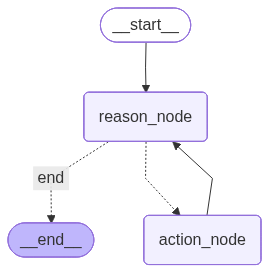

In [10]:
graph = StateGraph(GraphState)

graph.add_node('reason_node', reason_node)
graph.add_node('action_node', action_node)


def conditional_router(state: GraphState):
    if state['chat_history'][-1].tool_calls:
        return 'action_node'
    else:
        return 'end'

graph.add_edge(START, 'reason_node')
graph.add_conditional_edges('reason_node', conditional_router, {'action_node': 'action_node', 'end': END})
graph.add_edge('action_node', 'reason_node')


agent = graph.compile()

agent

In [11]:
user_id = '1' 
user_message = "I want to take leave tomorrow"

In [12]:
print("=" * 80)
print("🚀 Starting Agent Execution")
print("=" * 80)

for chunk in agent.stream({ 'user_id': user_id, 'chat_history' : [HumanMessage(content = user_message)] }, stream_mode="updates"):
    
    # Extract node name and data from chunk
    for node_name, node_data in chunk.items():
        print(f"\n{'─' * 80}")
        print(f"📍 Node: {node_name}")

        print(f"{'─' * 80}")
        
        # Check if there are messages in the chat_history
        if 'chat_history' in node_data:
            messages = node_data['chat_history']
            
            for msg in messages:
                # Handle AIMessage with tool calls
                if hasattr(msg, 'tool_calls') and msg.tool_calls:
                    print(f"\n🤖 AI is calling tools:")
                    for tool_call in msg.tool_calls:
                        print(f"   • Tool: {tool_call['name']}")
                        print(f"   • Args: {tool_call['args']}")
                
                # Handle ToolMessage (results from tools)
                elif isinstance(msg, ToolMessage):
                    print(f"\n🔧 Tool Result:")
                    print(f"   {msg.content}")
                
                # Handle AIMessage with content (final response)
                elif hasattr(msg, 'content') and msg.content:
                    print(f"\n💬 AI Response:")
                    print(f"   {msg.content}")

print(f"\n{'=' * 80}")
print("✅ Agent Execution Complete")
print("=" * 80)

🚀 Starting Agent Execution

────────────────────────────────────────────────────────────────────────────────
📍 Node: reason_node
────────────────────────────────────────────────────────────────────────────────

🤖 AI is calling tools:
   • Tool: get_time_off_balance
   • Args: {'user_id': '1'}

────────────────────────────────────────────────────────────────────────────────
📍 Node: action_node
────────────────────────────────────────────────────────────────────────────────

🔧 Tool Result:
   10

────────────────────────────────────────────────────────────────────────────────
📍 Node: reason_node
────────────────────────────────────────────────────────────────────────────────

🤖 AI is calling tools:
   • Tool: process_time_off
   • Args: {'user_id': '1', 'start_date': '2025-12-04', 'end_date': '2025-12-04'}

────────────────────────────────────────────────────────────────────────────────
📍 Node: action_node
────────────────────────────────────────────────────────────────────────────────



## Human in the loop



In [13]:
from langgraph.types import interrupt

In [14]:
# tools: 

@tool
def get_time_off_balance(user_id: str) -> int:
    '''
    Get the time off balance for a user. 

    Args :
        user_id: A unique string representing the user id

    Returns:
        An integer value representing the time-off balance
    '''
    return 10

@tool
def process_time_off(user_id: str, start_date: str, end_date: str) -> dict:
    '''
    Process time-off request for a user

    Args :
        user_id: A unique string representing the user id
        start_date: A date string in YYYY-MM-DD format for the start date of the time-off request
        end_date: A date string in YYYY-MM-DD format for the end date of the time-off request

    Returns:
        A dictionary with the following keys:
        - status: A string value representing the status of the time-off request
        - message: A string value representing the message of the time-off request
    '''
    start_date = datetime.strptime(start_date, "%Y-%m-%d")
    end_date = datetime.strptime(end_date, "%Y-%m-%d")

    days_requested = end_date - start_date
    time_off_balance = get_time_off_balance.invoke({"user_id": user_id})

    result = {}

    if days_requested.days + 1 > time_off_balance:
        result['status'] = 'error'
        result['message'] = f'Time off request failed. you only have {time_off_balance} days of remaining leaves but requested {days_requested.days} days'

    else:
        time_off_balance -= days_requested.days + 1
        result['status'] = 'success'
        result['message'] = f'Time off request processed successfully for {days_requested.days + 1} days. Your remaining time off balance is {time_off_balance}'


    return result


@tool
def get_additional_info_from_human( message: str) -> str:
    '''
        Raises an interrupt to fetch additional information from the human requesting the action

        Args:
            message: a message string from the AI requesting the user for missing information

        Returns:
            A string value representing the response with additional information from the human

    '''
    interrupt_result = interrupt(message)

    return interrupt_result['user_message']




# Graph execution gets suspended at the exact point where interrupt is called
# State is saved using the checkpointer so execution can be resumed later, In production, this should be a persistent checkpointer (e.g. backed by a database)
# Value is returned to the caller under __interrupt__; it can be any JSON-serializable value (string, object, array, etc.)
# Graph waits indefinitely until you resume execution with a response
# Response is passed back into the node when you resume, becoming the return value of the interrupt() call




In [15]:
# Key points about resuming:
# You must use the same thread ID when resuming that was used when the interrupt occurred
# The value passed to Command(resume=...) becomes the return value of the interrupt call
# The node restarts from the beginning of the node where the interrupt was called when resumed, so any code before the interrupt runs again
# You can pass any JSON-serializable value as the resume value

In [16]:
# nodes 

llm = init_chat_model(model="gpt-4o", temperature=0)
tools = [get_time_off_balance, process_time_off, get_additional_info_from_human ]
tools_by_name = {tool.name : tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)

def reason_node(state: GraphState) -> GraphState:

    user_id = state['user_id']

    prompt_template = ChatPromptTemplate(
            [
                ('system', ACTION_PROMPT_TEMPLATE)
            ]
            +
            state['chat_history']
            
        )

    chain = prompt_template | llm_with_tools

    todays_date = datetime.now().strftime("%Y-%m-%d")

    llm_response = chain.invoke({'todays_date': todays_date, 'user_id': user_id})

    return {
            'chat_history': [llm_response]
        }

def action_node(state: GraphState):
        
    result = []

    for tool_call in state['chat_history'][-1].tool_calls:
            tool = tools_by_name[tool_call["name"]]
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content= str(observation), tool_call_id=tool_call["id"]))

    return {
        'chat_history': result
    }

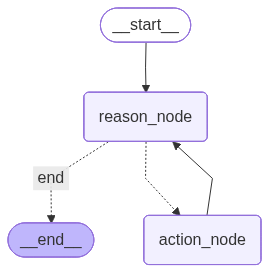

In [17]:
# Compile graph
from langgraph.checkpoint.memory import InMemorySaver

graph = StateGraph(GraphState)

graph.add_node('reason_node', reason_node)
graph.add_node('action_node', action_node)


def conditional_router(state: GraphState):
    if state['chat_history'][-1].tool_calls:
        return 'action_node'
    else:
        return 'end'

graph.add_edge(START, 'reason_node')
graph.add_conditional_edges('reason_node', conditional_router, {'action_node': 'action_node', 'end': END})
graph.add_edge('action_node', 'reason_node')

checkpointer = InMemorySaver()
agent = graph.compile(checkpointer=checkpointer)

agent

In [ ]:
# Human in the loop  in action

from langgraph.types import Command

user_id = '1' 
user_message = "I want to take leave"

config = {'configurable': {'thread_id': user_id}}

In [19]:

agent_input = {'user_id': user_id, 'chat_history' : [HumanMessage(content = user_message)]} # initial state

while True:
    interrupt_detected = False
    
    for chunk in agent.stream(agent_input, config=config , stream_mode="updates"):

        for node_name, node_data in chunk.items():
            print(f"\n{'─' * 80}")
            print(f"📍 Node: {node_name}")

            print(f"{'─' * 80}")

            if node_name == '__interrupt__':
                print(f"\n🔄 Interrupt for Human Input")
                print(f"   {node_data[0].value}")  

                interrupt_detected = True
                user_message = input("Human Input: ")
                agent_input = Command(resume={'user_message': user_message})
                
                break 
            
            
            # Check if there are messages in the chat_history
            if 'chat_history' in node_data:
                messages = node_data['chat_history']
                
                for msg in messages:
                    # Handle AIMessage with tool calls
                    if hasattr(msg, 'tool_calls') and msg.tool_calls:
                        print(f"\n🤖 AI is calling tools:")
                        for tool_call in msg.tool_calls:
                            print(f"   • Tool: {tool_call['name']}")
                            print(f"   • Args: {tool_call['args']}")
                    
                    # Handle ToolMessage (results from tools)
                    elif isinstance(msg, ToolMessage):
                        print(f"\n🔧 Tool Result:")
                        print(f"   {msg.content}")
                    
                    # Handle AIMessage with content (final response)
                    elif hasattr(msg, 'content') and msg.content:
                        print(f"\n💬 AI Response:")
                        print(f"   {msg.content}")
        
    
    if not interrupt_detected:
        print(f"\n{'=' * 80}")
        print("✅ Agent Execution Complete")
        print("=" * 80)
        
        break

        


────────────────────────────────────────────────────────────────────────────────
📍 Node: reason_node
────────────────────────────────────────────────────────────────────────────────

🤖 AI is calling tools:
   • Tool: get_additional_info_from_human
   • Args: {'message': 'Could you please specify the end date for your leave request?'}

────────────────────────────────────────────────────────────────────────────────
📍 Node: __interrupt__
────────────────────────────────────────────────────────────────────────────────

🔄 Interrupt for Human Input
   Could you please specify the end date for your leave request?

────────────────────────────────────────────────────────────────────────────────
📍 Node: action_node
────────────────────────────────────────────────────────────────────────────────

🔧 Tool Result:
   tomorrow

────────────────────────────────────────────────────────────────────────────────
📍 Node: reason_node
───────────────────────────────────────────────────────────────────────

In [22]:
checkpointer.get({'configurable': {'thread_id': user_id}})

In [21]:
# Clear checkpoints for a specific thread
checkpointer.delete_thread(thread_id = '1')